# Loading the dataset

In [2]:
!pip install -q faiss-cpu
!pip install -q transformers sentencepiece

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch

from transformers import (
    CLIPProcessor,
    CLIPModel,
    BlipProcessor,
    BlipForConditionalGeneration
)

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import faiss

In [8]:
styles = pd.read_csv(
    "/kaggle/input/fashion-product-images-small/styles.csv",
    on_bad_lines="skip"
)

styles.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [9]:
IMAGE_DIR = "/kaggle/input/fashion-product-images-small/images"

image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.endswith(".jpg")
]

print("Total Images:", len(image_files))

Total Images: 44441


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

clip_processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
2026-06-22 08:49:45.831929: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-22 08:49:45.832090: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-22 08:49:46.085240: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one h

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [11]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [7]:
print("Device:", device)

print(type(clip_model))
print(type(clip_processor))

Device: cpu
<class 'transformers.models.clip.modeling_clip.CLIPModel'>
<class 'transformers.models.clip.processing_clip.CLIPProcessor'>


In [12]:
from tqdm import tqdm

embeddings = []
valid_images = []

BATCH_SIZE = 64

for i in tqdm(range(0, len(image_files), BATCH_SIZE)):

    batch_files = image_files[i:i+BATCH_SIZE]

    images = []

    for img_name in batch_files:
        try:
            img_path = os.path.join(IMAGE_DIR, img_name)
            image = Image.open(img_path).convert("RGB")

            images.append(image)
            valid_images.append(img_name)

        except:
            continue

    if len(images) == 0:
        continue

    inputs = clip_processor(
        images=images,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        image_features = clip_model.get_image_features(**inputs)

    image_features = image_features.cpu().numpy()

    embeddings.append(image_features)

embeddings = np.vstack(embeddings)

print("Embedding Shape:", embeddings.shape)

100%|██████████| 695/695 [08:15<00:00,  1.40it/s]

Embedding Shape: (44441, 512)


In [13]:
np.save("/kaggle/working/image_embeddings.npy", embeddings)

print("Saved!")

Saved!


In [14]:
loaded = np.load("/kaggle/working/image_embeddings.npy")

print(loaded.shape)

(44441, 512)


In [15]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=128,
    random_state=42
)

embeddings_reduced = pca.fit_transform(embeddings)

print("Original Shape:", embeddings.shape)
print("Reduced Shape:", embeddings_reduced.shape)

Original Shape: (44441, 512)
Reduced Shape: (44441, 128)


In [16]:
from sklearn.cluster import KMeans

NUM_CLUSTERS = 500

kmeans = KMeans(
    n_clusters=NUM_CLUSTERS,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(embeddings_reduced)

print("Clusters Created:", len(set(cluster_labels)))

Clusters Created: 500


In [17]:
from sklearn.metrics.pairwise import euclidean_distances

representative_indices = []

for cluster_id in range(NUM_CLUSTERS):

    cluster_members = np.where(cluster_labels == cluster_id)[0]

    cluster_vectors = embeddings_reduced[cluster_members]

    centroid = kmeans.cluster_centers_[cluster_id].reshape(1, -1)

    distances = euclidean_distances(cluster_vectors, centroid)

    closest_member = cluster_members[np.argmin(distances)]

    representative_indices.append(closest_member)

print("Representative Products:", len(representative_indices))

Representative Products: 500


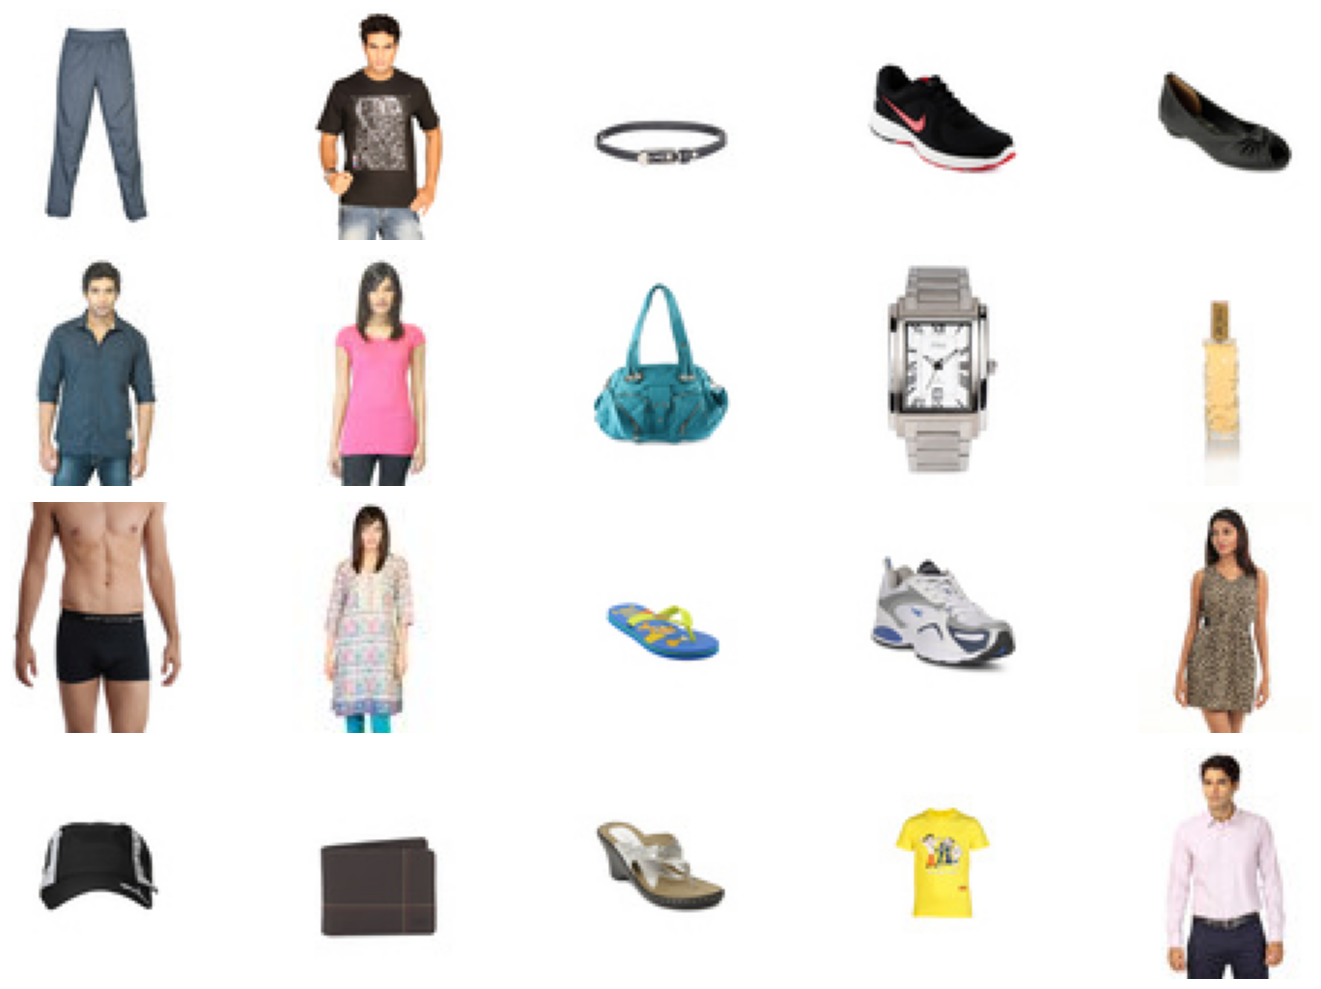

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

for i, idx in enumerate(representative_indices[:20]):

    img_path = os.path.join(
        IMAGE_DIR,
        valid_images[idx]
    )

    img = Image.open(img_path)

    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
catalog_images = [
    valid_images[idx]
    for idx in representative_indices
]

catalog_df = pd.DataFrame({
    "cluster_id": range(NUM_CLUSTERS),
    "representative_image": catalog_images
})

catalog_df.head()

,cluster_id,representative_image
0,0,7537.jpg
1,1,5831.jpg
2,2,38421.jpg
3,3,28637.jpg
4,4,17009.jpg


In [20]:
catalog_df.to_csv(
    "/kaggle/working/unique_catalog.csv",
    index=False
)

print("Catalog Saved!")

Catalog Saved!


In [21]:
print(embeddings.shape)
print(len(valid_images))

(44441, 512)
44441


In [23]:
from sklearn.metrics.pairwise import cosine_similarity

def search_products(query, top_k=5):

    inputs = clip_processor(
        text=[query],
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        text_features = clip_model.get_text_features(**inputs)

    text_features = text_features.cpu().numpy()

    similarities = cosine_similarity(
        text_features,
        embeddings
    )[0]

    top_indices = similarities.argsort()[-top_k:][::-1]

    return top_indices

In [24]:
results = search_products(
    "blue casual shirt",
    top_k=5
)

print(results)

[21704  9352 13542 22004  7006]


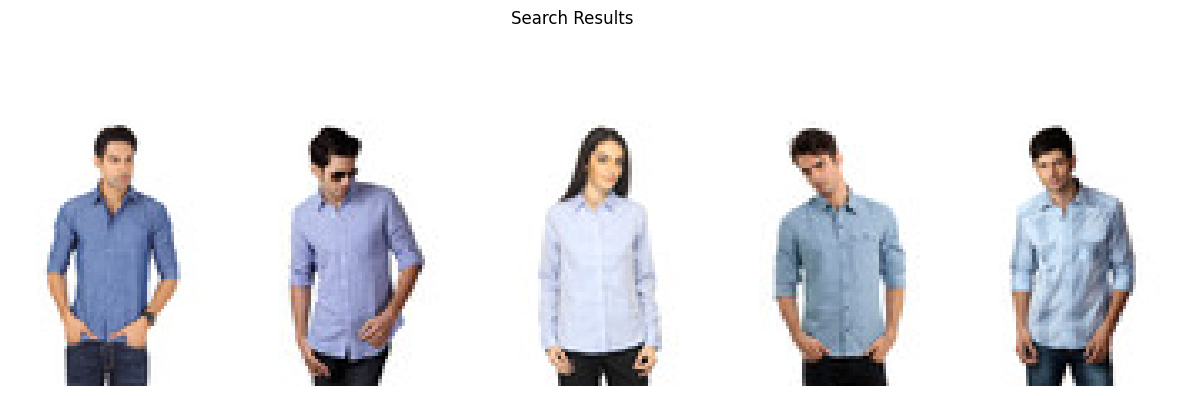

In [25]:
plt.figure(figsize=(15,5))

for i, idx in enumerate(results):

    img_path = os.path.join(
        IMAGE_DIR,
        valid_images[idx]
    )

    img = Image.open(img_path)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Search Results")
plt.show()

In [29]:
blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

print("BLIP Loaded!")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

BLIP Loaded!


In [30]:
sample_image = valid_images[0]

img_path = os.path.join(
    IMAGE_DIR,
    sample_image
)

image = Image.open(img_path).convert("RGB")

inputs = blip_processor(
    image,
    return_tensors="pt"
).to(device)

out = blip_model.generate(**inputs)

caption = blip_processor.decode(
    out[0],
    skip_special_tokens=True
)

print(caption)

/opt/conda/lib/python3.10/site-packages/transformers/generation/utils.py:1249: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


nike air pegasus black / blue


In [31]:
styles = pd.read_csv(
    "/kaggle/input/fashion-product-images-small/styles.csv",
    on_bad_lines="skip"
)

print(styles.columns)

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')


In [32]:
styles["id"] = styles["id"].astype(str)

category_lookup = {}

for _, row in styles.iterrows():
    category_lookup[row["id"]] = {
        "masterCategory": row["masterCategory"],
        "subCategory": row["subCategory"],
        "articleType": row["articleType"]
    }

print("Categories Loaded:", len(category_lookup))

Categories Loaded: 44424


In [33]:
sample_image = valid_images[0]

image_id = sample_image.replace(".jpg", "")

if image_id in category_lookup:
    print(category_lookup[image_id])
else:
    print("Category not found")

{'masterCategory': 'Footwear', 'subCategory': 'Shoes', 'articleType': 'Sports Shoes'}


In [34]:
sample_image = valid_images[0]

image_id = sample_image.replace(".jpg", "")

print("IMAGE:", sample_image)

if image_id in category_lookup:
    print("\nCATEGORY")
    print(category_lookup[image_id])

print("\nDESCRIPTION")
print(caption)

IMAGE: 31973.jpg

CATEGORY
{'masterCategory': 'Footwear', 'subCategory': 'Shoes', 'articleType': 'Sports Shoes'}

DESCRIPTION
nike air pegasus black / blue


In [35]:
original_products = 44441
final_catalog = 500

reduction = (
    (original_products - final_catalog)
    / original_products
) * 100

print(f"Original Products : {original_products}")
print(f"Final Catalog     : {final_catalog}")
print(f"Reduction (%)     : {reduction:.2f}")

Original Products : 44441
Final Catalog     : 500
Reduction (%)     : 98.87


In [36]:
queries = [
    "blue casual shirt",
    "red dress",
    "sports shoes",
    "black handbag"
]

for q in queries:
    print(f"\nQuery: {q}")
    print(search_products(q))


Query: blue casual shirt
[21704  9352 13542 22004  7006]

Query: red dress
[18129 23136 25333 26485 29481]

Query: sports shoes
[34716 11574  2035 29554 40182]

Query: black handbag
[42049  5168 26272 14104 21789]
